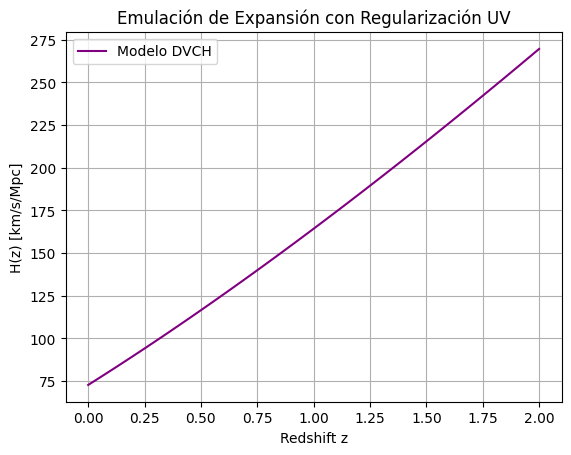

In [1]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

def emulacion_dvch(z_array, H0=73.0, Om0=0.3, n=-1.0, beta=0.01):
    # beta agrupa los términos de Planck: alpha * (l_p * H0 / c)^2
    E_z_soluciones = []

    for z in z_array:
        # Término de materia estándar
        rho_m_norm = Om0 * (1 + z)**3

        # Esta es la función implícita que fsolve debe hacer cero
        # E_guess es nuestra variable x a despejar (E(z) = H(z)/H0)
        def ecuacion_implicita(E_guess):
            numerador = rho_m_norm * (1 + z)**n
            denominador = 1 + beta * (E_guess**2)
            # rho_Lambda_norm basada en tu Ecuación 3
            rho_Lambda_norm = ((1 - Om0) / Om0) * (numerador / denominador)

            # E(z)^2 = rho_m_norm + rho_Lambda_norm
            # (Asumiendo radiación despreciable para simplificar el test)
            return E_guess**2 - (rho_m_norm + rho_Lambda_norm)

        # Resolvemos para E(z) usando un guess inicial de LambdaCDM
        guess_inicial = np.sqrt(Om0 * (1 + z)**3 + (1 - Om0))
        E_solucion = fsolve(ecuacion_implicita, guess_inicial)[0]
        E_z_soluciones.append(E_solucion)

    return np.array(E_z_soluciones) * H0

# Probamos la emulación en el rango observable
z_test = np.linspace(0, 2, 50)
Hz_dvch = emulacion_dvch(z_test)

plt.plot(z_test, Hz_dvch, label="Modelo DVCH", color='purple')
plt.xlabel("Redshift z")
plt.ylabel("H(z) [km/s/Mpc]")
plt.title("Emulación de Expansión con Regularización UV")
plt.legend()
plt.grid(True)
plt.show()